## Fluctuaciones termodinámicas
---

En física estadística, las fluctuaciones de variables termodinámicas alrededor del equilibrio siguen, en la aproximación gaussiana, una distribución **binormal**. Para un gas ideal en contacto con un reservorio, las fluctuaciones de temperatura $T$ y presión $P$ están correlacionadas.

Vamos a simular la variable $(T,P)$ 1000 veces, calcular la fracción de datos que caen dentro de la elipse $1\sigma$ y comparar con la probabilidad contenida dentro de dicha región.

## Parámetros

- $\mu_T = 300\,\mathrm{K}$, $\sigma_T = 5\,\mathrm{K}$
- $\mu_P = 101.3\,\mathrm{kPa}$, $\sigma_P = 2\,\mathrm{kPa}$
- Correlación $\rho = 0.6$ (temperatura y presión tienden a subir juntas)




In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import danatools

Text(0.5, 1.0, 'Datos simulados de variable binormal, $\\mu_T =300K$,  $\\mu_P = 101.3 KPa$, $\\sigma_T = 5K $, $\\sigma_P = 2 KPa$')

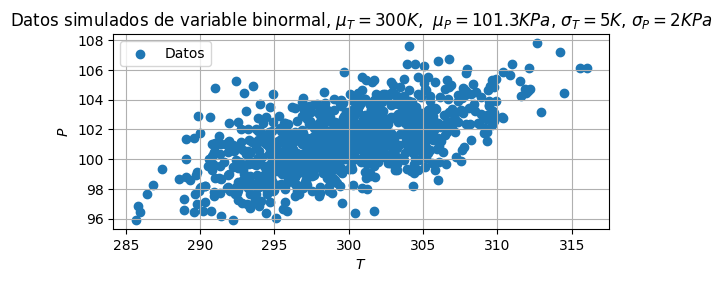

In [11]:
#Definimos los parámetros
mu = np.array([300.0, 101.3])   # (T en K, P en kPa)
sigma_T = 5.0       # K
sigma_P = 2.0       # kPa
rho = 0.6       # correlación
N = 1000        # número de simulaciones

#Generamos la matriz de covarianza
cov = danatools.covariance_matrix_2d(sigma_T, sigma_P, rho)

#Generamos los datos
X = np.random.multivariate_normal(mu, cov, size= N)

#Visualizamos los datos generados
plt.scatter(X[:,0],X[:,1], label = 'Datos')
plt.xlabel('$T$')
plt.ylabel('$P$')
plt.grid()
plt.legend()
plt.axis('scaled')
plt.title('Datos simulados de variable binormal, $\mu_T =300K$,  $\mu_P = 101.3 KPa$, $\sigma_T = 5K $, $\sigma_P = 2 KPa$')

Para ver cuántos puntos caen adentro utilizamos el hecho de que un punto $(x_1, x_2)$ pertenece a la elipse $r\sigma$ si la forma cuadrática asociada $q(x_1, x_2) ≤ r$.

Para calcular la forma cuadrática $q$, podemos escribirla como función de $x_1,x_2$, o podemos también usar la expresión vista en clase

$$q=(x-\mu)^T A (x-\mu)$$

donde $A$ es la matriz hessiana. En clase encontramos la expresión analítica, que podríamos escribir a mano, pero también mostramos que $A$  es la inversa de la matriz de covarianza, que ya tenemos calculada.

En esta celda calculamos $A$, y usamos la expresión de arriba para calcular $q$.

In [12]:
A = np.linalg.inv(cov) #Matriz hessiana

q = np.sum((X-mu).T*(A@(X-mu).T),axis = 0)

#la fracción que está adentro de la elipse 1sigma es
n_1sigma = np.count_nonzero(q<1)/N

print(n_1sigma) #debería dar ~0.39 (se puede mostrar haciendo un cambio de variables de Q a Chi_2 ^2 y calcular la acumulada F_2(1))

0.374


La expresión analítica de $q(x_1,x_2)$ es

$$q(x_1,x_2) = \left(\frac{x_{1}-\mu_{1}}{\sigma_{1}}\right)^{2}+\left(\frac{x_{2}-\mu_{2}}{\sigma_{2}}\right)^{2}$$

Puede verse que haciendo primero un cambio de variables para estandarizar cada término, y después notando que la expresión es una suma de variables al cuadrado, entonces $q(x_1,x_2) \sim \chi_2^2$.

Entonces, la probabilidad de que un par $(x_1,x_2)$ esté adentro de la elipse $r\sigma$ equivale a evaluar la distribución acumulada de una variable $\chi_2^2$, que es

$$F_2(q)=1-e^{-q/2}.$$

En particular, para la elipse $1\sigma$, es

$$F_2(1)=1-e^{-1/2}≈ 0.39,$$ 

que es cercano al valor obtenido para 1000 puntos, y esperamos que tienda a el valor teórico aumentando el número de puntos.

Por último, Si la probabilidad de obtener un punto en la elipse es $P≈0.39$ entonces esperamos que de $N$ puntos totales, $Np\approx 4$ caigan en la elipse.

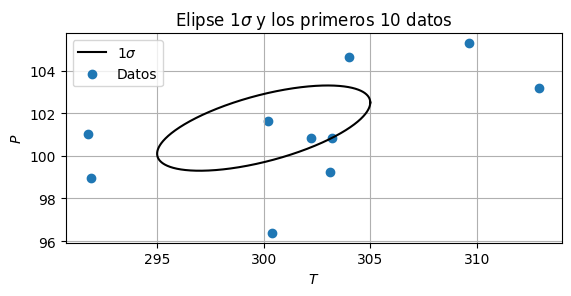

In [13]:
fig, ax = plt.subplots()

#grafico la elipse 1sigma
x, y = danatools.get_ellipse(mu, cov, nsigma=1)
ax.plot(x, y, color = 'black', label='$1\sigma$')

#y los primeros 10 datos
ax.set_title('Elipse $1\sigma$ y los primeros 10 datos')

ax.scatter(X[:10,0],X[:10,1], label = 'Datos')

plt.axis('scaled')
ax.set_xlabel('$T$')
ax.set_ylabel('$P$')
ax.grid()

ax.legend()

## Conclusiones

En resumen, simulamos una variable binormal, calculamos la fracción de datos que caen en la elipse $1\sigma$ y vimos que se asemeja a la cantidad esperada usando la función acumulada de una distribución $\chi_2^2$.

Además, graficamos los primeros 10 datos, y obtuvimos una cantidad cercana a lo esperado de puntos dentro de la elipse (aunque puede variar en cada corrida del notebook).